In [103]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors, rdchem, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV

def mol_to_feat(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    #算重要基团
    nitrate = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[OX2][N+](=O)[O-]")))
    nitro = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N+](=O)[O-]"))) - nitrate
    nitroso = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N;R0]=[O;D1]")))
    azide = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N-]=[N+]=N")))

    Wt = Descriptors.MolWt(mol)
    HeavyAtoms = Descriptors.HeavyAtomCount(mol)

    feat = [
        (C * 2 + H / 2 - O) * 16 / Wt,
        Descriptors.fr_Ar_N(mol) * 14 / Wt,
        nitrate / HeavyAtoms, nitro / HeavyAtoms, nitroso / HeavyAtoms, azide / HeavyAtoms,
        NN_single / sum, NN_double / sum, NO_single, NO_double
    ]

    desc_names = ['EState_VSA8', 'VSA_EState3', 'VSA_EState4', 'PEOE_VSA1', 'PEOE_VSA7', 'SlogP_VSA1', 'SlogP_VSA4']
    feat = feat + list(MoleculeDescriptors.MolecularDescriptorCalculator(desc_names).CalcDescriptors(mol))
    
    return feat

file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
x_all = np.stack(df["ROMol"].apply(mol_to_feat).tolist(), axis = 0)
y_all = np.array(df["Q(cal/g)"], dtype = np.float64)

for i in range(5):
    pipe = make_pipeline(PolynomialFeatures(i + 1), StandardScaler(), LassoCV(cv = 5))
    scores = cross_validate(pipe, x_all, y_all, cv = 10, scoring = ["neg_mean_squared_error", "r2"], n_jobs = -1)
    mse = np.abs(scores["test_neg_mean_squared_error"]).mean()
    r2 = scores["test_r2"]
    print(i + 1, mse, r2, r2.mean(), sep = ' ')


1 77272.56872839811 [0.39300897 0.6133543  0.50166367 0.70835299 0.07919896 0.22487022
 0.79340532 0.73338987 0.00879101 0.82897501] 0.4885010314901077
2 64492.55807054648 [0.50598198 0.57591879 0.79573094 0.69878797 0.50746571 0.20870942
 0.82469598 0.78308267 0.25638173 0.82833674] 0.5985091942278171
3 68156.59438445896 [0.51583204 0.51389664 0.7947241  0.66155775 0.4878416  0.52686261
 0.88334315 0.85747414 0.48239503 0.01341667] 0.5737343721201513
4 53117.111450997625 [0.55285678 0.44066107 0.79965746 0.77063555 0.57449934 0.60080601
 0.80766484 0.88879604 0.64709549 0.79780227] 0.6880474851535132
5 55609.18540805902 [0.56859062 0.44034396 0.85718592 0.80816287 0.74218245 0.62944946
 0.80949192 0.89605227 0.78743245 0.29017474] 0.6829066666893149


0.7579369062687298


,x_test,y_test,predict
0,,496.140963,683.142273
1,,1423.136578,1323.713867
2,,1715.825161,1545.943604
3,,1287.918346,1060.581421
4,,1414.255200,1394.703369
5,,1987.835622,1507.817017
6,,2174.959096,1515.151855
7,,360.927144,655.680542
8,,1558.058212,1335.300171
9,,1713.492486,1929.578003

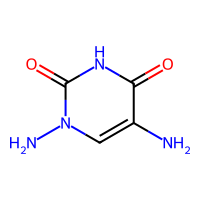
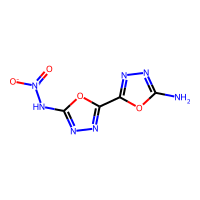
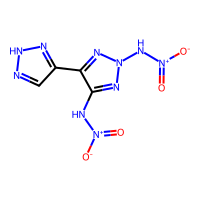
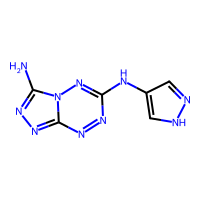
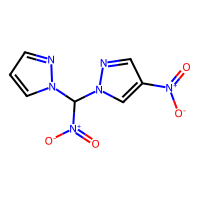
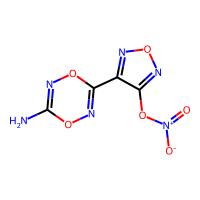
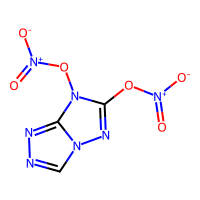
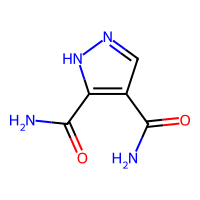
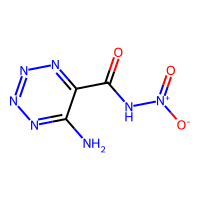
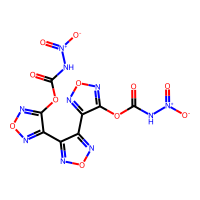
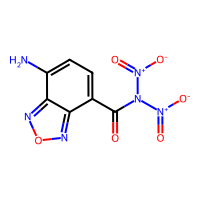
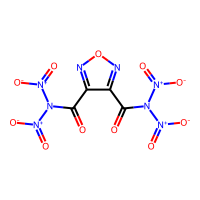
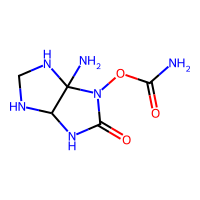
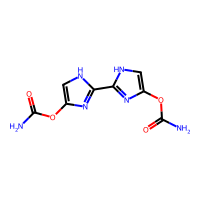
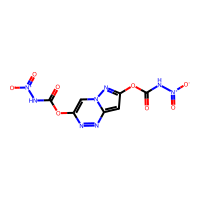
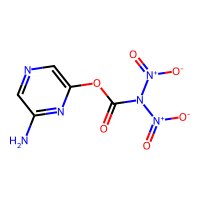
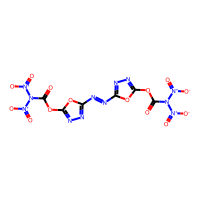
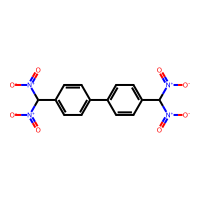

In [102]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors, rdchem, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
from skfp.model_selection import scaffold_train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

def mol_to_feat(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()
    
    nitrate = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[OX2][N+](=O)[O-]")))
    nitro = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N+](=O)[O-]"))) - nitrate
    nitroso = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N;R0]=[O;D1]")))

    Wt = Descriptors.MolWt(mol)
    HeavyAtoms = Descriptors.HeavyAtomCount(mol)

    feat = [
        (C * 2 + H / 2 - O) * 16 / Wt,
        Descriptors.fr_Ar_N(mol) * 14 / Wt,
        NO_double / sum, NN_single, NN_double
    ]

    desc_names = ['EState_VSA8', 'VSA_EState3', 'PEOE_VSA1', 'PEOE_VSA7', "SlogP_VSA1", "SlogP_VSA4"]
    feat = feat + list(MoleculeDescriptors.MolecularDescriptorCalculator(desc_names).CalcDescriptors(mol))

    return feat

file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
x_train, x_test, y_train, y_test = scaffold_train_test_split(df["ROMol"], df["Q(cal/g)"])
df1 = pd.DataFrame({
    "x_test": x_test,
    "y_test": y_test
})

clf = XGBRegressor(
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 6,
    reg_lambda = 1.0,
    n_jobs = -1,
    random_state = 323922
)

x_train = np.stack([mol_to_feat(mol) for mol in x_train], axis = 0)
x_test = np.stack([mol_to_feat(mol) for mol in x_test], axis = 0)
clf.fit(x_train, y_train)
y_pre = clf.predict(x_test)

PandasTools.RenderImagesInAllDataFrames(images = True)
df1["predict"] = y_pre
print(r2_score(y_test, y_pre))
df1

In [2]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, rdchem
import numpy as np

def mol_to_feat(mol):
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    feat = [
        (C * 2 + H / 2 - O) * 16 / Descriptors.MolWt(mol),
        N * 14 / Descriptors.MolWt(mol),
        NO_single / sum, NO_double / sum,
        NN_single / sum, NN_double / sum
    ]
    return feat
    

f = mol_to_feat(Chem.MolFromSmiles("O=[N+]([O-])Oc1nn2cnnc2n1O[N+](=O)[O-]"))
f

[0.03461944574267366,
 0.42408821034775235,
 0.29411764705882354,
 0.11764705882352941,
 0.0,
 0.11764705882352941]

In [78]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import PandasTools, Descriptors, rdchem, rdMolDescriptors
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def mol_to_feat(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    #算重要基团
    nitrate = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[OX2][N+](=O)[O-]")))
    nitro = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N+](=O)[O-]"))) - nitrate
    nitroso = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N;R0]=[O;D1]")))
    azide = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[N-]=[N+]=N")))

    Wt = Descriptors.MolWt(mol)
    HeavyAtoms = Descriptors.HeavyAtomCount(mol)

    feat = [
        (C * 2 + H / 2 - O) * 16 / Wt,
        Descriptors.fr_Ar_N(mol) * 14 / Wt,
        nitrate / HeavyAtoms, nitro / HeavyAtoms, nitroso / HeavyAtoms, azide / HeavyAtoms,
        NN_single / sum, NN_double / sum, NO_single, NO_double
    ]

    desc_names = ['EState_VSA8', 'VSA_EState3', 'VSA_EState4', 'PEOE_VSA1', 'PEOE_VSA7', 'SlogP_VSA1', 'SlogP_VSA4']
    feat = feat + list(MoleculeDescriptors.MolecularDescriptorCalculator(desc_names).CalcDescriptors(mol))
    
    return feat

file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)

data = df["ROMol"].apply(mol_to_feat).tolist()
desc_name = ["OB*", "fr_Ar_N", "nitrate", "nitro", "nitroso", "azide", "NN_single", "NN_double", "NO_single", "NO_double", 'EState_VSA8', 'VSA_EState3', 'VSA_EState4', 'PEOE_VSA1', 'PEOE_VSA7', 'SlogP_VSA1', 'SlogP_VSA4']
df2 = pd.DataFrame(data, columns = desc_name)

corr = df2.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
df2 = df2.drop(columns = to_drop)

Importances = RandomForestRegressor().fit(df2.values, df["Q(cal/g)"]).feature_importances_
feature_importances = pd.Series(Importances, index = df2.columns)
print(feature_importances.sort_values(ascending = False))

kbest_selector = SelectKBest(score_func = mutual_info_regression, k = 7)
df2_kbest = kbest_selector.fit_transform(df2.values, df["Q(cal/g)"])
selected_columns = df2.columns[kbest_selector.get_support()]
df3 = pd.DataFrame(df2_kbest, columns = selected_columns)
print(kbest_selector.scores_[kbest_selector.get_support()])
df3

VSA_EState3    0.433296
OB*            0.260533
EState_VSA8    0.092830
nitro          0.038840
NO_double      0.038388
fr_Ar_N        0.031416
PEOE_VSA7      0.022855
NN_double      0.017727
PEOE_VSA1      0.016635
VSA_EState4    0.012071
SlogP_VSA1     0.010098
NN_single      0.010002
NO_single      0.008499
nitrate        0.006811
azide          0.000000
dtype: float64
[0.5941581  0.38896807 0.2962882  0.36860085 0.45389507 0.15770919
 0.16476956]


,OB*,nitro,NO_single,NO_double,VSA_EState3,PEOE_VSA1,PEOE_VSA7
0,1.013243,0.000000,0.0,0.0,0.000000,11.548437,0.000000
1,0.412926,0.066667,1.0,1.0,22.385921,14.554019,0.000000
2,0.374792,0.111111,2.0,2.0,32.128086,10.114318,15.725183
3,1.099989,0.000000,0.0,0.0,22.362116,11.029530,0.000000
4,0.873351,0.117647,2.0,2.0,28.437707,0.000000,6.042419
...,...,...,...,...,...,...,...
83,0.128294,0.115385,4.0,5.0,34.801790,0.000000,10.575479
84,0.682985,0.071429,1.0,1.0,15.317528,10.456580,0.000000
85,0.603383,0.000000,2.0,1.0,5.451154,21.076207,0.000000
86,-0.068350,0.187500,3.0,3.0,42.940208,0.000000,10.446506
